In [1]:
import class_Planet, class_Star, class_Disk, class_Molecule
import numpy as np
import matplotlib.pyplot as plt
import corner


In [2]:
st = class_Star.Star()

In [3]:
pl_measurements = {}
pl_measurements['S'] = np.random.normal(10., 3., 1000)
pl_measurements['C'] = np.random.normal(15., 2.5, 1000)
pl_measurements['O'] = np.random.normal(20.5, 2.5, 1000)

planet = class_Planet.Planet(st, pl_measurements)
planet.set_planet_mass(1., 0.1)
planet.get_metal_mass()

/Users/ychachan/Research/Tools/accomp/class_Planet.py:17: RuntimeWarning: invalid value encountered in log10
  self.abund_dict[sp] = star.abundance_dict[sp] + np.log10(self.measured_abund[sp])


In [4]:
mol_dict = class_Molecule.MoleculeDict(st)
mol_dict.set_default_composition()

Putting remaining element fraction for C in refractory
Putting remaining element fraction for O in refractory
Putting remaining element fraction for S in refractory


In [5]:
disk = class_Disk.Disk(st)
solid_comp, gas_comp = disk.get_solid_gas_composition(50., mol_dict)

In [6]:
mol_dict.get_mol_Tcond()

{'Al': 2000.0,
 'Ca': 2000.0,
 'Si': 1600.0,
 'Mg': 1600.0,
 'Fe': 1600.0,
 'Ni': 1600.0,
 'O_refractory': 1600.0,
 'Na': 1100.0,
 'NH4SH': 300.0,
 'C_refactory': 300.0,
 'S_refactory': 300.0,
 'H2O': 170.0,
 'H2S': 90.0,
 'CO2': 70.0,
 'NH3': 70.0,
 'CO': 30.0,
 'N2': 25.0,
 'Ne': 25.0,
 'Ar': 25.0}

In [7]:
mol_dict.get_mol_Tcond().values()

dict_values([2000.0, 2000.0, 1600.0, 1600.0, 1600.0, 1600.0, 1600.0, 1100.0, 300.0, 300.0, 300.0, 170.0, 90.0, 70.0, 70.0, 30.0, 25.0, 25.0, 25.0])

/Users/ychachan/anaconda3/envs/py39/lib/python3.9/site-packages/corner/core.py:915: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return ax.set_xlim(new_xlim)


(1.0, 31.622776601683793)

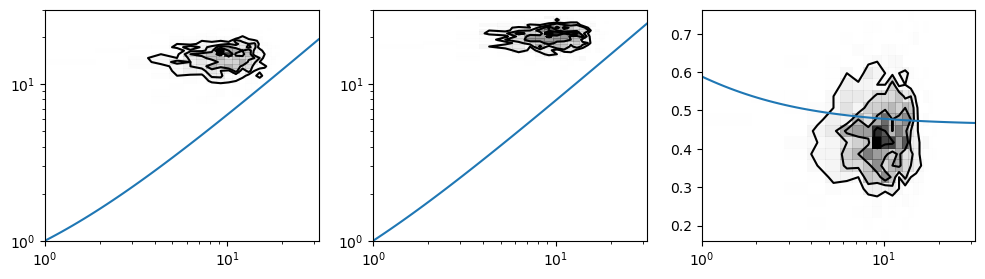

In [8]:
S_to_H_vary = np.logspace(0, 1.5)
predicted_comp = disk.assemble_planet(S_to_H_vary, solid_comp, gas_comp)

fig, axs = plt.subplots(ncols=3, figsize=(12, 3), sharex=True)

corner.hist2d(pl_measurements['S'], pl_measurements['C'], ax=axs[0], plot_datapoints=False)
axs[0].loglog(S_to_H_vary, predicted_comp['C'])

corner.hist2d(pl_measurements['S'], pl_measurements['O'], ax=axs[1], plot_datapoints=False)
axs[1].loglog(S_to_H_vary, predicted_comp['O'])

corner.hist2d(pl_measurements['S'], pl_measurements['C'] / pl_measurements['O'] * st.CtoO, ax=axs[2], plot_datapoints=False)
axs[2].semilogx(S_to_H_vary, predicted_comp['C'] / predicted_comp['O'] * st.CtoO)

axs[0].set_ylim(1, 30)
axs[1].set_ylim(1, 30)
axs[2].set_xlim(S_to_H_vary[0], S_to_H_vary[-1])

In [9]:
planet.get_metal_mass_breakdown(solid_comp, gas_comp, 'S')

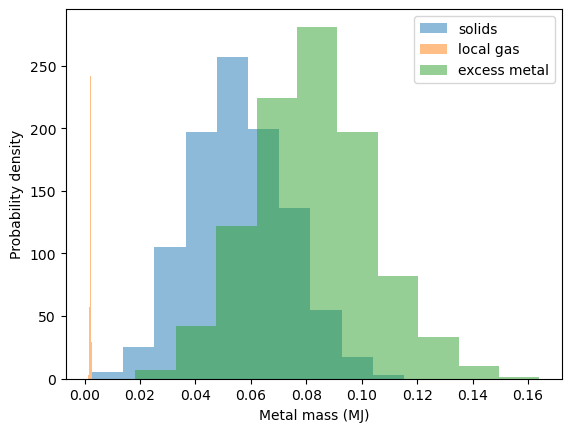

In [10]:
plt.figure()
plt.hist(planet.metal_mass_solids, alpha=0.5, label='solids')
plt.hist(planet.metal_mass_local_gas, alpha=0.5, label='local gas')
plt.hist(planet.metal_mass_excess_metal, alpha=0.5, label='excess metal')

plt.xlabel('Metal mass (MJ)')
plt.ylabel('Probability density')

plt.legend()